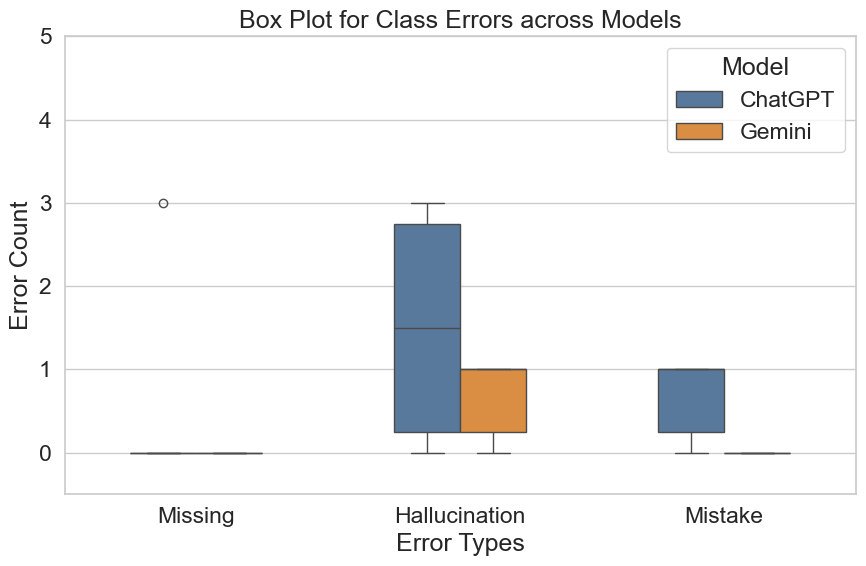

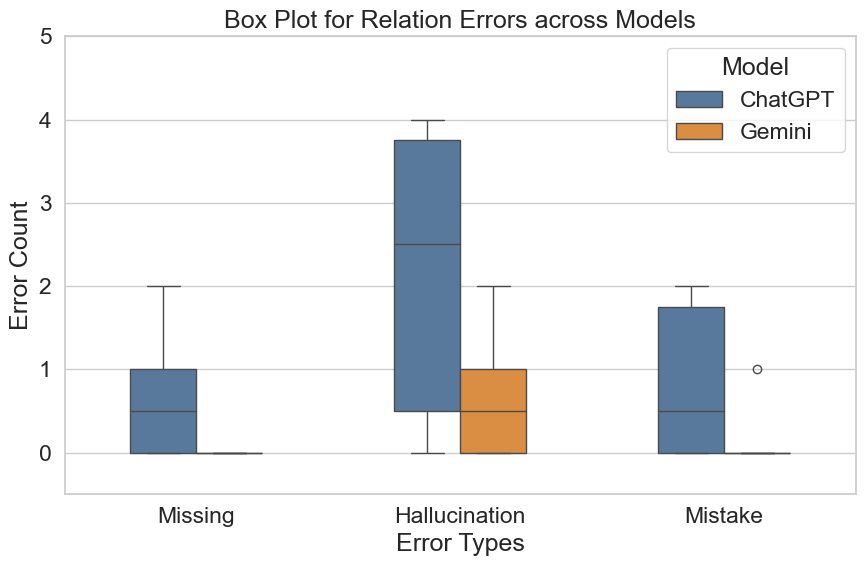

In [21]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np

# Load the Excel file
file_path = 'Task_1_Summary.xlsx'
excel_data = pd.ExcelFile(file_path)

# Load sheets
chatgpt_df = excel_data.parse('ChatGPT', header=1)
gemini_df  = excel_data.parse('Gemini', header=1)
# claude_df  = excel_data.parse('Claude', header=1)
# mistral_df = excel_data.parse('Mistral', header=1)

# Rename columns for consistency
cols = ['Code', 'Missing_Class', 'Hallucination_Class', 'Mistake_Class',
        'Missing_Relation', 'Hallucination_Relation', 'Mistake_Relation']
chatgpt_df.columns = cols
gemini_df.columns = cols
# claude_df.columns = cols
# mistral_df.columns = cols

# Add model identifiers
chatgpt_df['Model'] = 'ChatGPT'
gemini_df['Model'] = 'Gemini'
# claude_df['Model'] = 'Claude'
# mistral_df['Model'] = 'Mistral'

# Combine all data
combined_df = pd.concat([chatgpt_df, gemini_df], ignore_index=True)
# combined_df = pd.concat([chatgpt_df, gemini_df, claude_df, mistral_df], ignore_index=True)

# Define columns for 'Class' and 'Relation'
class_columns = ['Missing_Class', 'Hallucination_Class', 'Mistake_Class']
relation_columns = ['Missing_Relation', 'Hallucination_Relation', 'Mistake_Relation']

# Melt the data for plotting
melted_class_df = combined_df.melt(
    id_vars=['Model'],
    value_vars=class_columns,
    var_name='Error Type',
    value_name='Values'
)

melted_relation_df = combined_df.melt(
    id_vars=['Model'],
    value_vars=relation_columns,
    var_name='Error Type',
    value_name='Values'
)

# Labels for x ticks
class_labels_map = {
    'Missing_Class': 'Missing',
    'Hallucination_Class': 'Hallucination',
    'Mistake_Class': 'Mistake'
}
relation_labels_map = {
    'Missing_Relation': 'Missing',
    'Hallucination_Relation': 'Hallucination',
    'Mistake_Relation': 'Mistake'
}

melted_class_df['Error Type'] = melted_class_df['Error Type'].map(class_labels_map)
melted_relation_df['Error Type'] = melted_relation_df['Error Type'].map(relation_labels_map)

# Custom colors for each model
custom_palette = {
    'ChatGPT': '#4E79A7',
    'Gemini':  '#F28E2B',
    # 'Claude':  '#E15759',
    # 'Mistral': '#76B7B2'
}

# Optional: set a seaborn theme
sns.set_theme(style="whitegrid", font_scale=1.5)

# -------------------------
# SAME Y-SCALE FOR BOTH PLOTS
# -------------------------
# Compute a common upper bound across both datasets (ignore NaN)
global_max = np.nanmax([
    melted_class_df['Values'].max(),
    melted_relation_df['Values'].max()
])

# Make it an integer and add a small margin so the top isn't tight
y_max = int(np.ceil(global_max)) + 1

# (Optional) if you want to start exactly from 0
y_min = -0.5

# New output filenames
pdf_class_out = "boxplot_task1_class_errors_chatgpt_vs_gemini.pdf"
pdf_relation_out = "boxplot_task1_relation_errors_chatgpt_vs_gemini.pdf"

# -------------------------
# 1) CLASS plot (PDF)
# -------------------------
plt.figure(figsize=(9, 6))
ax1 = sns.boxplot(
    data=melted_class_df,
    x='Error Type',
    y='Values',
    hue='Model',
    palette=custom_palette,
    width=0.5,
    dodge=True
)
ax1.set_title('Box Plot for Class Errors across Models', fontsize=18)
ax1.set_xlabel('Error Types')
ax1.set_ylabel('Error Count')

# Same scale
ax1.set_ylim(y_min, y_max)

# only integer ticks on y-axis
ax1.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(pdf_class_out, format='pdf')
plt.show()

# -------------------------
# 2) RELATION plot (PDF)
# -------------------------
plt.figure(figsize=(9, 6))
ax2 = sns.boxplot(
    data=melted_relation_df,
    x='Error Type',
    y='Values',
    hue='Model',
    palette=custom_palette,
    width=0.5,
    dodge=True
)
ax2.set_title('Box Plot for Relation Errors across Models', fontsize=18)
ax2.set_xlabel('Error Types')
ax2.set_ylabel('Error Count')

# Same scale
ax2.set_ylim(y_min, y_max)

# only integer ticks on y-axis
ax2.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(pdf_relation_out, format='pdf')
plt.show()


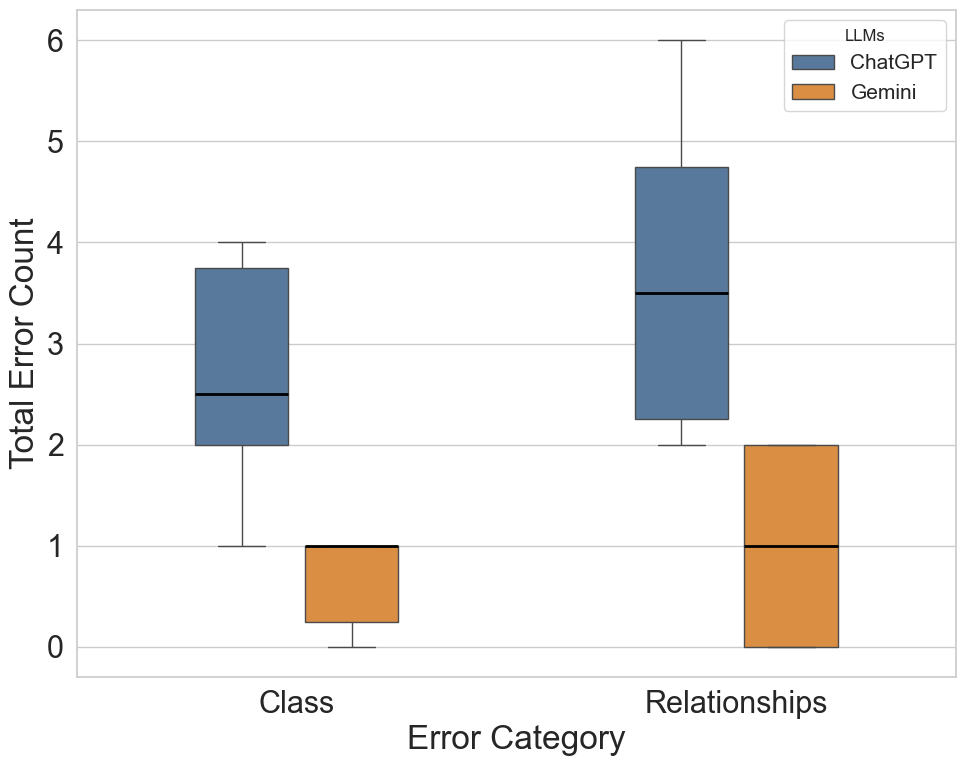

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
file_path = 'Task_1_macro.xlsx'
excel_data = pd.ExcelFile(file_path)

# Prepare a combined DataFrame for plotting
combined_data = pd.DataFrame()

# Loop through each sheet and add the data to the combined DataFrame
for sheet in ['ChatGPT', 'Gemini']:
    df = excel_data.parse(sheet)
    # Adding a column to indicate the sheet name (source) for each row
    df['Source'] = sheet
    combined_data = pd.concat([combined_data, df[['Class', 'Relationships', 'Source']]])

# Melt the combined data for easier box plotting
melted_data = pd.melt(
    combined_data,
    id_vars='Source',
    value_vars=['Class', 'Relationships'],
    var_name='Metric',
    value_name='Value'
)

# Define custom color mapping for each source
color_palette = {
    'ChatGPT': '#4E79A7',
    'Gemini': '#F28E2B'
    # 'Claude': '#E15759',
    # 'Mistral': '#76B7B2'
}

# Plotting with custom colors
plt.figure(figsize=(10, 8))
sns.boxplot(
    data=melted_data,
    x='Metric',
    y='Value',
    hue='Source',
    gap=0.15,
    width=0.5,
    dodge=True,
    palette=color_palette,
    medianprops={"color": "black", "linewidth": 2}
)

plt.ylabel("Total Error Count", fontsize=24)
plt.xlabel("Error Category", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.legend(title="LLMs", fontsize=15, title_fontsize=12)

plt.tight_layout()

# Save as PDF (instead of PNG)
output_file_path = 'macro_box_plots_Class_Rel.pdf'
plt.savefig(output_file_path, format='pdf')

# Show plot
plt.show()
